https://velog.io/@jochedda/%ED%81%B4%EB%9F%AC%EC%8A%A4%ED%84%B0%EB%A7%81-%ED%8F%89%EA%B0%80%EC%A7%80%ED%91%9C-%EC%8B%A4%EB%A3%A8%EC%97%A3-%EA%B3%84%EC%88%98Silhouette-Coefficient

In [ ]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']
irisDF = pd.DataFrame(data = iris.data,columns = feature_names)
kmeans = KMeans(n_clusters = 3, init = 'k-means++',max_iter = 300, random_state=42).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

average_coef = silhouette_score(iris.data,irisDF['cluster'])
print(f'평균 실루엣 값:{average_coef:.4f}')

#평균 실루엣 값 (silhouette score) = 0.5512라면, 결론부터 말하면 “군집이 꽤 잘 나뉜 편이다 (중간 이상, 양호)”라고 해석하면 됩니다.

# 🔎 실루엣 계수 기준 먼저 이해

# 실루엣 값은 -1 ~ 1 사이 값을 가집니다.

# 1에 가까울수록 👉 군집이 매우 잘 분리됨
# 0 근처 👉 군집이 서로 겹침
# 음수 👉 잘못 군집됨 (다른 군집이 더 가까움)


# 🌸 Iris 데이터 기준으로 보면

# Iris dataset 은 원래 3개의 클래스가 있음:

# Setosa 👉 매우 잘 분리됨
# Versicolor / Virginica 👉 서로 약간 겹침

# 그래서 보통:

# 0.5 ~ 0.6 정도가 나오면 정상
# 0.55면 👉 딱 평균 이상 잘 된 결과

irisDF.head(10)

평균 실루엣 값:0.5512


,sepal_length,sepal_width,petal_length,petal_width,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


In [2]:
# 😼 데이터 하나하나의 실루엣 계수를 살펴보자
score_samples = silhouette_samples(iris.data,irisDF['cluster'])
irisDF['silhouette_coeff'] = score_samples
irisDF

,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797
3,4.6,3.1,1.5,0.2,1,0.804352
4,5.0,3.6,1.4,0.2,1,0.848918
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0.424561
146,6.3,2.5,5.0,1.9,2,0.103125
147,6.5,3.0,5.2,2.0,0,0.316810
148,6.2,3.4,5.4,2.3,0,0.347855


In [3]:
# 😸 군집별 실루엣 평균 계수를 살펴보자
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.436842
1,0.797604
2,0.422323


In [ ]:
# ❗️❗️ 그렇지만 실루엣 계수만으로 그룹화가 잘되었다 판단할 수 없기 때문에 시각화를 해보아야 한다.

In [5]:
def visualize_silhouette(cluster_lists,X_features):
  from sklearn.datasets import make_blobs
  from sklearn.cluster import KMeans
  from sklearn.metrics import silhouette_samples, silhouette_score
  import matplotlib.pyplot as plt
  import matplotlib.cm as cm
  import math

  n_cols = len(cluster_lists) #입력값으로 클러스터링 갯수를 받아서 갯수별로 클러스터링 적용 후 실루엣 계수 계산
  fig,axs = plt.subplots(figsize=(4*n_cols,4),nrows = 1,ncols = n_cols)
  #클러스터링 갯수의 순서대로 적힌 클러스터링의 수만큼 sub figures를 가지는 axs 생성
  for ind, n_cluster in enumerate(cluster_lists):
    clusterer = KMeans(n_clusters = n_cluster, max_iter = 500,random_state = 0)
    cluster_labels = clusterer.fit_predict(X_features)

    sil_avg = silhouette_score(X_features,cluster_labels)
    sil_values = silhouette_samples(X_features,cluster_labels)
    y_lower = 10
    axs[ind].set_title('Number of Cluster: '+str(n_cluster)+'\n'+'Shilhouette Score:'+str(round(sil_avg,3)))
    axs[ind].set_xlabel('The silhouette coefficient values')
    axs[ind].set_ylabel('Cluster label')
    axs[ind].set_xlim([-0.1,1])
    axs[ind].set_ylim([0,len(X_features)+(n_cluster+1)*10])
    axs[ind].set_yticks([])
    axs[ind].set_xticks([0,0.2,0.4,0.6,0.8,1])
    #클러스터링 갯수별로 fill_betweenx 형태의 막대 그래프 표현 
    for i in range(n_cluster):
      ith_cluster_sil_values = sil_values[cluster_labels==i]
      ith_cluster_sil_values.sort()

      size_cluster_i = ith_cluster_sil_values.shape[0]
      y_upper = y_lower + size_cluster_i
      
      color = cm.nipy_spectral(float(i)/n_cluster)
      axs[ind].fill_betweenx(np.arange(y_lower,y_upper),0,ith_cluster_sil_values,facecolor = color,edgecolor = color, alpha = 0.7)
      axs[ind].text(-0.05,y_lower+0.5*size_cluster_i,str(i))
      y_lower = y_upper +10

    axs[ind].axvline(x = sil_avg,color = "red",linestyle = "--")

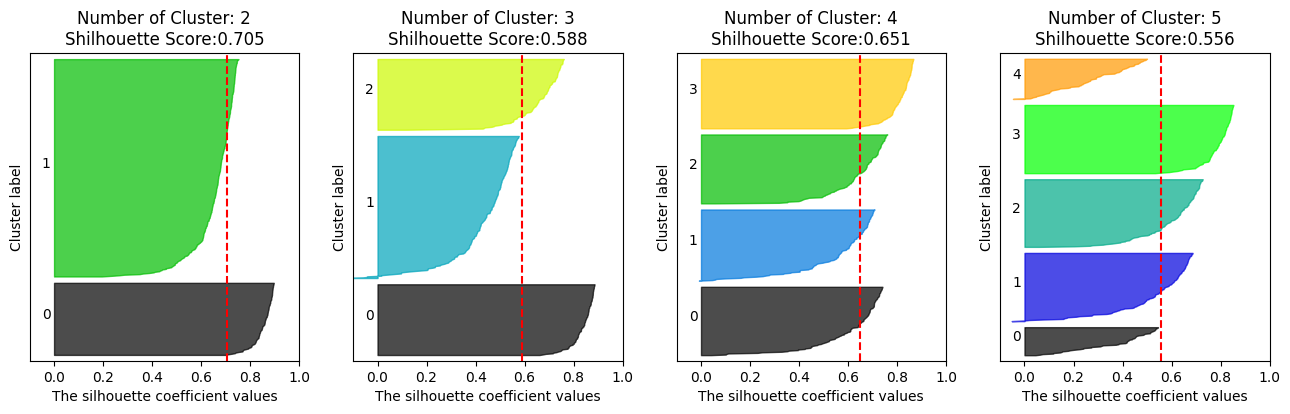

In [7]:
from sklearn.datasets import make_blobs
#make_blobs를 통해 clustering을 위한 4개의 클러스터 중심의 500개 2차원 데이터 셋 생성 
X,y = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1,center_box=(-10.0,10.0),shuffle = True,random_state = 1)

visualize_silhouette([2,3,4,5],X)

In [ ]:
# 각 군집별로 실루엣 스코어를 나타냈다
# 실루엣 스코어만 보았을 때 군집의 개수가 2일 때가 최적화 같지만 군집간의 편차가 적은 군집이 3이나 4일때가 더 좋다!
# 따라서 이러한 문제 때문에 군집 수 최적화는 시각화도 같이 봐서 판단해야 한다



평균 실루엣 점수: 0.5512


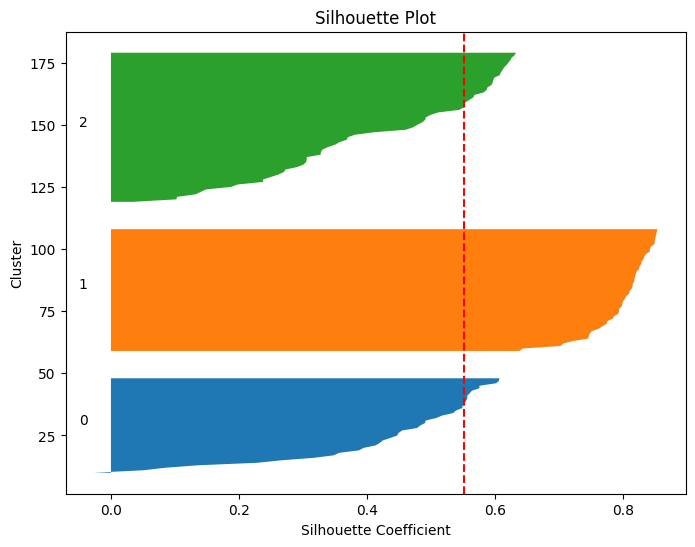

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 데이터 로드
iris = load_iris()
X = iris.data

# KMeans 수행
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# 평균 실루엣 점수
silhouette_avg = silhouette_score(X, cluster_labels)
print(f"평균 실루엣 점수: {silhouette_avg:.4f}")

# 각 샘플의 실루엣 값
sample_silhouette_values = silhouette_samples(X, cluster_labels)

# 시각화
y_lower = 10
n_clusters = 3

plt.figure(figsize=(8, 6))

for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0,
                      ith_cluster_silhouette_values)
    
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

# 평균 실루엣 점수 라인
plt.axvline(x=silhouette_avg, color="red", linestyle="--")

plt.title("Silhouette Plot")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")

plt.show()